In [1]:

import numpy as np
from pyscf import gto, scf, cc

# mol = gto.M(atom="H 0 0 0; H 0 0 2", basis="sto6g", unit='B', verbose=0)
a = 2 # bond length in a cluster
d = 100 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 2 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
basis = 'sto6g'
# for nc in nc_list:
atoms = ""
for n in range(nc * na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
mol = gto.M(atom=atoms,basis=basis,spin=spin*nc,unit=unit,verbose=4)

mf = scf.RHF(mol)
mf.kernel()
print(f"RHF  energy: {mf.e_tot:.10f} Ha")

mycc = cc.CCSD(mf)
mycc.kernel()
print(f"CCSD energy: {mycc.e_tot:.10f} Ha")

System: uname_result(system='Linux', node='yichi-thinkpad', release='4.4.0-26100-Microsoft', version='#7920-Microsoft Fri Jan 01 08:00:00 PST 2016', machine='x86_64')  Threads 12
Python 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]
numpy 1.24.3  scipy 1.14.1  h5py 3.12.1
Date: Tue Mar 24 22:31:27 2026
PySCF version 2.8.0
PySCF path  /home/yichi/research/software/lno_pyscf
GIT HEAD (branch master) ef75f4190e4de208685670651dc6c467f72b6794

[ENV] PYSCF_EXT_PATH /home/yichi/research/software/pyscf
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 4
[INPUT] num. electrons = 4
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = b
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000

In [3]:
from ad_afqmc_prototype import config
config.configure_once() 
import jax.numpy as jnp

In [12]:
from ad_afqmc_prototype.staging import stage #, _stage_ham_input, _stage_trial_input
from ad_afqmc_prototype.staging import StagedMfOrCc
from ad_afqmc_prototype.ham.chol import HamChol
from ad_afqmc_prototype.trial.rhf import RhfTrial
# from ad_afqmc_prototype.trial.cisd import CisdTrial

guide_obj = StagedMfOrCc(mycc._scf, norb_frozen=None)
trial_obj = StagedMfOrCc(mycc, norb_frozen=None)
# staged_ham = _stage_ham_input(objmf, chol_cut=1e-5, verbose=False)
# staged_guide = _stage_trial_input(objmf)

# ham_data = HamChol(
#     h0=jnp.array(staged_ham.h0),
#     h1=jnp.array(staged_ham.h1),
#     chol=jnp.array(staged_ham.chol),
#     basis=staged_ham.basis,
# )

# guide_data = RhfTrial(
#     mo_coeff=jnp.array(staged_guide.data['mo'][:,:nocc]),
#     )

# objcc = StagedMfOrCc(mycc, norb_frozen=None)
# objcc.kind = 'pt2ccsd'
# staged_trial = _stage_trial_input(objcc)
# trial_data = CisdTrial(
#     ci1 = staged_trial.data["ci1"],
#     ci2 = staged_trial.data["ci2"],
#     )
# staged_trial = _stage_trial_input(objcc)

# trial_data = Pt2ccsdTrial(
#     mo_t = staged_trial.data["mo_t"],
#     t2 = staged_trial.data["t2"],
#     )

In [18]:
from ad_afqmc_prototype.core.system import System

staged_guide = stage(mycc._scf)
ham = staged_guide.ham
sys = System(norb=int(ham.norb), nelec=ham.nelec, walker_kind="restricted")
ham_data = HamChol(
    jnp.asarray(ham.h0), 
    jnp.asarray(ham.h1), 
    jnp.asarray(ham.chol), 
    basis=ham.basis
    )

In [ ]:
staged_guide = _stage_trial_input(guide_obj)
guide_data = RhfTrial(
    mo_coeff=jnp.array(staged_guide.data['mo'][:,:nocc]),
    )
trial_data = Pt2ccsdTrial(
    mo_t = staged_trial.data["mo_t"],
    t2 = staged_trial.data["t2"],
    )

In [6]:
# ── Step 5: build Pt2CCSDMeasCtx — precomputed measurement arrays ────────────

trial_cfg      = Pt2ccsdMeasCfg(memory_mode="low")
trial_meas_ctx = build_meas_ctx(ham_data, trial_data, trial_cfg)

print(trial_meas_ctx)

Pt2ccsdMeasCtx(cfg=Pt2ccsdMeasCfg(memory_mode='low', mixed_real_dtype=<class 'jax.numpy.float64'>, mixed_complex_dtype=<class 'jax.numpy.complex128'>, mixed_real_dtype_testing=<class 'jax.numpy.float32'>, mixed_complex_dtype_testing=<class 'jax.numpy.complex64'>))


In [9]:
from ad_afqmc_prototype.core.system import System
from ad_afqmc_prototype.trial.rhf import make_rhf_trial_ops
from ad_afqmc_prototype.meas.rhf  import make_rhf_meas_ops
# from ad_afqmc_prototype.meas.cisd  import make_cisd_meas_ops
from ad_afqmc_prototype.prop.afqmc import make_prop_ops, init_prop_state
from ad_afqmc_prototype.prop.types import QmcParams
# from ad_afqmc_prototype.prop.blocks import block as qmc_block

sys   = System(norb=norb, nelec=(nocc, nocc), walker_kind="restricted")
guide_ops = make_rhf_trial_ops(sys)
guide_meas_ops  = make_rhf_meas_ops(sys)
guide_prop_ops  = make_prop_ops(ham_data.basis, sys.walker_kind)
trial_meas_ops  = make_pt2ccsd_meas_ops(sys, mixed_precision=False)

params = QmcParams(
    dt            = 0.005,   # imaginary-time step
    n_walkers     = 300,      # walker population
    n_prop_steps  = 50,      # propagation steps per block
    n_blocks      = 300,     # sampling blocks
    n_eql_blocks  = 50,      # equilibration blocks (discarded)
    seed          = 17,
)

print(f"dt={params.dt}  n_walkers={params.n_walkers}  n_prop_steps={params.n_prop_steps}")
print(f"equlibrium imaginary time: {params.n_eql_blocks * params.n_prop_steps * params.dt:.2f} a.u.")
print(f"sampling imaginary time: {params.n_blocks * params.n_prop_steps * params.dt:.2f} a.u.")

dt=0.005  n_walkers=300  n_prop_steps=50
equlibrium imaginary time: 12.50 a.u.
sampling imaginary time: 75.00 a.u.


In [10]:
from ad_afqmc_prototype import walkers as wk

def get_init_pt2trial_energy(
        init_state, 
        ham_data, 
        trial_data, 
        trial_meas_ops, 
        trial_meas_ctx, 
        ):
    walker_0 = wk.take_walkers(init_state.walkers, jnp.array([0]))
    trial_e_kernel = trial_meas_ops.require_kernel(k_energy)
    t2, e0, e1 = wk.vmap_chunked(trial_e_kernel, n_chunks=1, in_axes=(0, None, None, None))(
            walker_0, ham_data, trial_meas_ctx, trial_data)
     
    trial_overlap = wk.vmap_chunked(trial_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
        walker_0, trial_data
    )
    guide_overlap = init_state.overlaps[0]
    trial_weights = init_state.weights * trial_overlap / guide_overlap
    trial_energy = (ham_data.h0 + e0 + e1 - t2 * e1).mean()

    return trial_energy+0j, jnp.sum(trial_weights)

In [14]:
state = init_prop_state(
    sys        = sys,
    ham_data   = ham_data,
    trial_ops  = guide_ops,
    trial_data = guide_data,
    meas_ops   = guide_meas_ops,
    params     = params,
)

print(f"Initial walker batch shape: {state.walkers.shape}")
print(f"Initial weights (first 5):  {state.weights[:5]}")
print(f"Initial e_estimate: {float(state.e_estimate):.8f} Ha")
print(f"PYSCF-HF Energy: {float(mf.e_tot):.8f} Ha")
print(f"Initial mean |overlap|: {float(jnp.mean(jnp.abs(state.overlaps))):.6f}")

Initial walker batch shape: (200, 4, 2)
Initial weights (first 5):  [1. 1. 1. 1. 1.]
Initial e_estimate: -2.11285976 Ha
PYSCF-HF Energy: -2.11285976 Ha
Initial mean |overlap|: 1.000000


In [16]:
energy, weights = get_init_pt2trial_energy(state, ham_data, trial_data, trial_meas_ops, trial_meas_ctx, )
print(energy, weights)
print(mycc.e_tot)

(-2.192142566015619+0j) (200+0j)
-2.1921425660156215


In [11]:
from typing import Any, Callable, NamedTuple, Protocol

import jax
import jax.numpy as jnp
from jax import lax, tree_util

from ad_afqmc_prototype import walkers as wk
from ad_afqmc_prototype.core.levels import LevelPack
from ad_afqmc_prototype.core.ops import MeasOps, TrialOps, k_energy
from ad_afqmc_prototype.core.system import System
from ad_afqmc_prototype.walkers import SrFn
from ad_afqmc_prototype.prop.types import PropOps, PropState, QmcParams, QmcParamsFp
from ad_afqmc_prototype.prop.blocks import BlockObs

# def block_mixed(
#     state: PropState,
#     *,
#     sys: System,
#     params: QmcParams,
#     ham_data: Any,
#     guide_data: Any,
#     guide_ops: TrialOps,
#     guide_meas_ops: MeasOps,
#     guide_meas_ctx: Any,
#     guide_prop_ops: PropOps,
#     guide_prop_ctx: Any,
#     trial_data: Any,
#     trial_meas_ops: MeasOps,
#     trial_meas_ctx: Any,
#     observable_names: tuple[str, ...] = (),
#     sr_fn: Callable = wk.stochastic_reconfiguration,
# ) -> tuple[PropState, BlockObs]:
#     """
#     Block function for mixed sampling -- Trial =! Guide
#     propagation(Guide) + measurement(Trial)
#     """

#     # propagation is guided with the guiding wavefunction 
#     step = lambda st: guide_prop_ops.step(
#         st,
#         params     = params,
#         ham_data   = ham_data,
#         trial_data = guide_data,
#         trial_ops  = guide_ops,
#         meas_ops   = guide_meas_ops,
#         prop_ctx   = guide_prop_ctx,
#         meas_ctx   = guide_meas_ctx,
#     )

#     def _scan_step(carry: PropState, _x: Any):
#         carry = step(carry)
#         return carry, None

    # state, _ = lax.scan(_scan_step, state, xs=None, length=params.n_prop_steps)

    # walkers_new = wk.orthonormalize(state.walkers, sys.walker_kind)
    # guide_overlaps = wk.vmap_chunked(guide_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
    #     walkers_new, guide_data
    # )
    # state = state._replace(walkers=walkers_new, overlaps=guide_overlaps)

    # # some measurements with the guiding wavefunction if necessary
    # guide_e_kernel = guide_meas_ops.require_kernel(k_energy)
    # guide_e_samples = wk.vmap_chunked(guide_e_kernel, n_chunks=params.n_chunks, in_axes=(0, None, None, None))(
    #     state.walkers, ham_data, guide_meas_ctx, guide_data
    # ) # local energy with respect to the guiding wavefunction = <guide|H|walker>/<guide|walker>
    # guide_e_samples = jnp.real(guide_e_samples)

    # thresh = jnp.sqrt(2.0 / jnp.asarray(params.dt))
    # e_ref = state.e_estimate
    # is_nan = ~jnp.isfinite(guide_e_samples)
    # guide_e_samples = jnp.where(is_nan | (jnp.abs(guide_e_samples - e_ref) > thresh), e_ref, guide_e_samples)

    # guide_weights = jnp.where(is_nan, 0.0, state.weights)
    # guide_w_sum = jnp.sum(guide_weights)
    # guide_w_sum_safe = jnp.where(guide_w_sum == 0, 1.0, guide_w_sum)
    # guide_e_block = jnp.sum(guide_weights * guide_e_samples) / guide_w_sum_safe
    # guide_e_block = jnp.where(guide_w_sum == 0, e_ref, guide_e_block)

    # alpha = jnp.asarray(params.shift_ema, dtype=jnp.result_type(guide_e_block))
    # state = state._replace(
    #     weights=guide_weights,
    #     e_estimate=(1.0 - alpha) * state.e_estimate + alpha * guide_e_block,
    # )

    # # measuing with respect to trial
    # trial_e_kernel = trial_meas_ops.require_kernel(k_energy)
    # trial_e_samples = wk.vmap_chunked(trial_e_kernel, n_chunks=params.n_chunks, in_axes=(0, None, None, None))(
    #     state.walkers, ham_data, trial_meas_ctx, trial_data
    # )
    # trial_overlaps = wk.vmap_chunked(trial_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
    #     walkers_new, trial_data
    # )
    # trial_weights = guide_weights * trial_overlaps / guide_overlaps # w_trial = w_guide * <G|walker>/<T|walker>
    # trial_w_sum = jnp.sum(trial_weights)
    # trial_e_block = jnp.sum(trial_weights * trial_e_samples) / trial_w_sum
    # # trial_e_components = jnp.sum(trial_weights[:, None] * trial_e_samples, axis=0) / trial_w_sum
    # # t2, e0, e1 = 

    # obs_samples: dict[str, jax.Array] = {}
    # # for name in observable_names:
    # #     kernel = meas_ops.require_observable(name)
    # #     samples = wk.vmap_chunked(kernel, n_chunks=params.n_chunks, in_axes=(0, None, None, None))(
    # #         state.walkers, ham_data, guide_meas_ctx, guide_data
    # #     )
    # #     w_shape = (weights.shape[0],) + (1,) * max(samples.ndim - 1, 0)
    # #     num = jnp.sum(weights.reshape(w_shape) * samples, axis=0)
    # #     zero = jnp.zeros_like(num)
    # #     obs_samples[name] = jnp.where(wg_sum == 0, zero, num / w_sum_safe)
    
    # # performing SR at the end of Block propagation and measurement (Guide)
    # key, subkey = jax.random.split(state.rng_key)
    # zeta = jax.random.uniform(subkey)
    # w_sr, weights_sr = sr_fn(state.walkers, state.weights, zeta, sys.walker_kind)
    # overlaps_sr = wk.vmap_chunked(guide_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
    #     w_sr, guide_data
    # )
    # state = state._replace(
    #     walkers=w_sr,
    #     weights=weights_sr,
    #     overlaps=overlaps_sr,
    #     rng_key=key,
    # )

    # obs = BlockObs(
    #     scalars = {
    #         "guide_weight": guide_w_sum,
    #         "guide_energy": guide_e_block,
    #         "trial_weight": trial_w_sum,
    #         "trial_energy": trial_e_block,
    #         },
    #     observables = obs_samples,
    # )
    # return state, obs

In [12]:
def block_mixed(
    state: PropState,
    *,
    sys: System,
    params: QmcParams,
    ham_data: Any,
    guide_data: Any,
    guide_ops: TrialOps,
    guide_meas_ops: MeasOps,
    guide_meas_ctx: Any,
    guide_prop_ops: PropOps,
    guide_prop_ctx: Any,
    trial_data: Any,
    trial_meas_ops: MeasOps,
    trial_meas_ctx: Any,
    observable_names: tuple[str, ...] = (),
    sr_fn: Callable = wk.stochastic_reconfiguration,
) -> tuple[PropState, BlockObs]:
    """
    Block function for mixed sampling -- Trial =! Guide
    propagation(Guide) + measurement(Trial)
    """

    # propagation is guided with the guiding wavefunction 
    step = lambda st: guide_prop_ops.step(
        st,
        params     = params,
        ham_data   = ham_data,
        trial_data = guide_data,
        trial_ops  = guide_ops,
        meas_ops   = guide_meas_ops,
        prop_ctx   = guide_prop_ctx,
        meas_ctx   = guide_meas_ctx,
    )

    def _scan_step(carry: PropState, _x: Any):
        carry = step(carry)
        return carry, None

    state, _ = lax.scan(_scan_step, state, xs=None, length=params.n_prop_steps)

    walkers_new = wk.orthonormalize(state.walkers, sys.walker_kind)
    guide_overlaps = wk.vmap_chunked(guide_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
        walkers_new, guide_data
    )
    state = state._replace(walkers=walkers_new, overlaps=guide_overlaps)

    # some measurements with the guiding wavefunction if necessary
    guide_e_kernel = guide_meas_ops.require_kernel(k_energy)
    guide_e_samples = wk.vmap_chunked(guide_e_kernel, n_chunks=params.n_chunks, in_axes=(0, None, None, None))(
        state.walkers, ham_data, guide_meas_ctx, guide_data
    ) # local energy with respect to the guiding wavefunction = <guide|H|walker>/<guide|walker>
    guide_e_samples = jnp.real(guide_e_samples)

    thresh = jnp.sqrt(2.0 / jnp.asarray(params.dt))
    e_ref = state.e_estimate
    is_nan = ~jnp.isfinite(guide_e_samples)
    guide_e_samples = jnp.where(is_nan | (jnp.abs(guide_e_samples - e_ref) > thresh), e_ref, guide_e_samples)

    guide_weights = jnp.where(is_nan, 0.0, state.weights)
    guide_w_block = jnp.sum(guide_weights)
    guide_w_block_safe = jnp.where(guide_w_block == 0, 1.0, guide_w_block)
    guide_e_block = jnp.sum(guide_weights * guide_e_samples) / guide_w_block_safe
    guide_e_block = jnp.where(guide_w_block == 0, e_ref, guide_e_block)

    alpha = jnp.asarray(params.shift_ema, dtype=jnp.result_type(guide_e_block))
    state = state._replace(
        weights=guide_weights,
        e_estimate=(1.0 - alpha) * state.e_estimate + alpha * guide_e_block,
    )

    # measuing with respect to trial
    trial_e_kernel = trial_meas_ops.require_kernel(k_energy)
    trial_t2s, trial_e0s, trial_e1s = wk.vmap_chunked(
        trial_e_kernel, n_chunks=params.n_chunks, in_axes=(0, None, None, None))(
        state.walkers, ham_data, trial_meas_ctx, trial_data
    )
    trial_overlaps = wk.vmap_chunked(trial_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
        walkers_new, trial_data
    )
    trial_weights = guide_weights * trial_overlaps / guide_overlaps # w_trial = w_guide * <G|walker>/<T|walker>
    trial_w_block = jnp.sum(trial_weights)
    trial_t2_block = jnp.sum(trial_weights * trial_t2s) / trial_w_block
    trial_e0_block = jnp.sum(trial_weights * trial_e0s) / trial_w_block
    trial_e1_block = jnp.sum(trial_weights * trial_e1s) / trial_w_block
    # trial_e_block = jnp.sum(trial_weights * trial_e_samples) / trial_w_sum
    # trial_e_parts_block = jnp.sum(trial_weights[:, None] * trial_e_parts, axis=0) / trial_w_block
    # trial_t2_block, trial_e0_block, trial_e1_block = trial_e_parts_block

    obs_samples: dict[str, jax.Array] = {}
    # for name in observable_names:
    #     kernel = meas_ops.require_observable(name)
    #     samples = wk.vmap_chunked(kernel, n_chunks=params.n_chunks, in_axes=(0, None, None, None))(
    #         state.walkers, ham_data, guide_meas_ctx, guide_data
    #     )
    #     w_shape = (weights.shape[0],) + (1,) * max(samples.ndim - 1, 0)
    #     num = jnp.sum(weights.reshape(w_shape) * samples, axis=0)
    #     zero = jnp.zeros_like(num)
    #     obs_samples[name] = jnp.where(wg_sum == 0, zero, num / w_sum_safe)
    
    # performing SR at the end of Block propagation and measurement (Guide)
    key, subkey = jax.random.split(state.rng_key)
    zeta = jax.random.uniform(subkey)
    w_sr, weights_sr = sr_fn(state.walkers, state.weights, zeta, sys.walker_kind)
    overlaps_sr = wk.vmap_chunked(guide_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
        w_sr, guide_data
    )
    state = state._replace(
        walkers=w_sr,
        weights=weights_sr,
        overlaps=overlaps_sr,
        rng_key=key,
    )

    obs = BlockObs(
        scalars = {
            "guide_weight": guide_w_block,
            "guide_energy": guide_e_block,
            "trial_weight": trial_w_block,
            "trial_t2"    : trial_t2_block,
            "trial_e0"    : trial_e0_block,
            "trial_e1"    : trial_e1_block,
            },
        observables = obs_samples,
    )
    return state, obs

In [13]:
from typing import Any

import jax
import jax.numpy as jnp
# from jax import lax, tree_util

# from ad_afqmc_prototype import walkers as wk
# from ad_afqmc_prototype.core.levels import LevelPack
from ad_afqmc_prototype.core.ops import MeasOps, TrialOps, k_energy
from ad_afqmc_prototype.core.system import System
# from ad_afqmc_prototype.walkers import SrFn
from ad_afqmc_prototype.prop.types import PropOps, QmcParamsBase
from ad_afqmc_prototype.prop.blocks import BlockFn
# from ad_afqmc_prototype.stat_utils import blocking_analysis_ratio, jackknife_ratios, rebin_observable, reject_outliers
# from ad_afqmc_prototype.walkers import stochastic_reconfiguration

# from jax import lax
# from jax.sharding import Mesh, NamedSharding
from jax.sharding import PartitionSpec as P

# from ad_afqmc_prototype.driver import QmcResult, make_run_blocks
from functools import partial

def make_run_mixed_blocks(
    *,
    mixed_block_fn: Any,
    sys: System,
    params: QmcParamsBase,
    guide_ops: TrialOps,
    guide_meas_ops: MeasOps,
    guide_prop_ops: PropOps,
    trial_meas_ops: MeasOps,
    observable_names: tuple[str, ...] = (),
) -> Callable:
    """
    Build a jitted run_blocks for mixed sampling (Trial =! Guide).
    We keep ham_data, trial_data, meas_ctx, prop_ctx as arguments to
    improve compilation, as these objects can be large.
    """

    @partial(jax.jit, static_argnames=("n_blocks",))
    def run_mixed_blocks(
        state0,
        *,
        ham_data,
        guide_data,
        guide_meas_ctx,
        guide_prop_ctx,
        trial_data,
        trial_meas_ctx,
        n_blocks: int,
    ):
        def one_block(state, _):
            state, obs = mixed_block_fn(
                state,
                sys              = sys,
                params           = params,
                ham_data         = ham_data,
                guide_data       = guide_data,
                guide_ops        = guide_ops,
                guide_meas_ops   = guide_meas_ops,
                guide_meas_ctx   = guide_meas_ctx,
                guide_prop_ops   = guide_prop_ops,
                guide_prop_ctx   = guide_prop_ctx,
                trial_data       = trial_data,
                trial_meas_ops   = trial_meas_ops,
                trial_meas_ctx   = trial_meas_ctx,
                observable_names = observable_names,
            )
            obs_tuple = tuple(obs.observables[name] for name in observable_names)
            return state, (obs.scalars, obs_tuple)

        stateN, (scalars, obs) = lax.scan(one_block, state0, xs=None, length=n_blocks)
        return stateN, scalars, obs

    return run_mixed_blocks

In [ ]:
# def get_init_pt2trial_energy(
#         init_state, 
#         ham_data, 
#         trial_data, 
#         trial_meas_ops, 
#         trial_meas_ctx, 
#         ):
#     walker_0 = wk.take_walkers(init_state.walkers, jnp.array([0]))
#     trial_e_kernel = trial_meas_ops.require_kernel(k_energy)
#     t2, e0, e1 = wk.vmap_chunked(trial_e_kernel, n_chunks=1, in_axes=(0, None, None, None))(
#             walker_0, ham_data, trial_meas_ctx, trial_data)
     
#     trial_overlap = wk.vmap_chunked(trial_meas_ops.overlap, n_chunks=params.n_chunks, in_axes=(0, None))(
#         walker_0, trial_data
#     )
#     guide_overlap = init_state.overlaps[0]
#     trial_weights = init_state.weights * trial_overlap / guide_overlap
#     trial_energy = (ham_data.h0 + e0 + e1 - t2 * e1).mean()

#     return trial_energy+0j, jnp.sum(trial_weights)

In [ ]:
# walker_0 = wk.take_walkers(state.walkers, jnp.array([0]))
# trial_e_kernel = trial_meas_ops.require_kernel(k_energy)
# t2, e0, e1 = wk.vmap_chunked(trial_e_kernel, n_chunks=1, in_axes=(0, None, None, None))(
#         walker_0, ham_data, trial_meas_ctx, trial_data
#     )

In [ ]:
# ham_data.h0 + e0 + e1 - t2 * e1

Array([-2.19214257+0.j], dtype=complex128)

In [14]:
def pt2ccsd_blocking(h0, weights, t2_sp, e0_sp, e1_sp, printQ=False):
    nsample = len(weights)
    max_size = nsample // 10
    block_errs = [] # jnp.zeros(max_size)
    if printQ:
        print('Performing Blocking Analysis for AFQMC/pt2CCSD energy...')
        print('blk_SZ  Nblk  Nsmp  Energy  Error')
    for i, block_size in enumerate(range(1,max_size+1)):
        n_blocks = nsample // block_size

        wt_truncated = weights[:n_blocks * block_size]
        # t1_truncated = t1_clean[:n_blocks * block_size]
        t2_truncated = t2_sp[:n_blocks * block_size]
        e0_truncated = e0_sp[:n_blocks * block_size]
        e1_truncated = e1_sp[:n_blocks * block_size]

        # wt_t1 = wt_truncated * t1_truncated
        wt_t2 = wt_truncated * t2_truncated
        wt_e0 = wt_truncated * e0_truncated
        wt_e1 = wt_truncated * e1_truncated

        wt = wt_truncated.reshape(n_blocks, block_size)
        # wt_t1 = wt_t1.reshape(n_blocks, block_size)
        wt_t2 = wt_t2.reshape(n_blocks, block_size)
        wt_e0 = wt_e0.reshape(n_blocks, block_size)
        wt_e1 = wt_e1.reshape(n_blocks, block_size)

        block_wt = jnp.sum(wt, axis=1)
        # block_t1 = np.sum(wt_t1, axis=1)# / block_wt
        block_t2 = jnp.sum(wt_t2, axis=1) / block_wt
        block_e0 = jnp.sum(wt_e0, axis=1) / block_wt
        block_e1 = jnp.sum(wt_e1, axis=1) / block_wt

        block_energy = (h0 + block_e0 + block_e1 - block_t2*block_e0).real # (block_num / block_den).real
        block_mean = jnp.mean(block_energy)
        block_error = jnp.std(block_energy, ddof=1) / np.sqrt(n_blocks)
        if printQ:
            print(f' {block_size:3d}  {n_blocks:3d}  {block_size*n_blocks:4d}  {block_mean:.6f}  {block_error:.6f}')
        # block_size[i] = b
        # energy[i] = block_mean
        block_errs.append(block_error)
    
    wt_avg = jnp.mean(weights)
    t2_avg = jnp.mean(weights * t2_sp) / wt_avg
    e0_avg = jnp.mean(weights * e0_sp) / wt_avg
    e1_avg = jnp.mean(weights * e1_sp) / wt_avg
    energy_avg = h0 + e0_avg + e1_avg - t2_avg*e0_avg

    find_err = False
    for i, err in enumerate(block_errs):
        if jnp.abs((err - block_errs[i-1]) / err) < 0.04:
            find_err = True
            break

    if not find_err:
        err = jnp.array(block_errs).max()

    return energy_avg.real, err.real

In [15]:
from typing import Any

import jax
import jax.numpy as jnp
# from jax import lax, tree_util

# from ad_afqmc_prototype import walkers as wk
# from ad_afqmc_prototype.core.levels import LevelPack
# from ad_afqmc_prototype.core.ops import MeasOps, TrialOps, k_energy
# from ad_afqmc_prototype.core.system import System
# from ad_afqmc_prototype.walkers import SrFn
# from ad_afqmc_prototype.prop.types import PropOps, PropState, QmcParams
# from ad_afqmc_prototype.prop.blocks import BlockFn
from ad_afqmc_prototype.stat_utils import blocking_analysis_ratio, reject_outliers
from ad_afqmc_prototype.walkers import stochastic_reconfiguration
# from ad_afqmc_prototype.driver import QmcResult

# from jax import lax
from jax.sharding import Mesh, NamedSharding
from jax.sharding import PartitionSpec as P

# from ad_afqmc_prototype.driver import make_run_blocks
from functools import partial
import time
print = partial(print, flush=True)

class MixedBlockFn(Protocol):
    def __call__(
        self,
        state: PropState,
        *,
        sys: System,
        params: QmcParams,
        ham_data: Any,
        guide_data: Any,
        guide_ops: TrialOps,
        guide_meas_ops: MeasOps,
        guide_meas_ctx: Any,
        guide_prop_ops: PropOps,
        guide_prop_ctx: Any,
        trial_data: Any,
        trial_meas_ops: MeasOps,
        trial_meas_ctx: Any,
        observable_names: tuple[str, ...] = (),
        sr_fn: Callable = wk.stochastic_reconfiguration,
    ) -> tuple[PropState, BlockObs]: ...

class MixedQmcResult(NamedTuple):
    guide_mean_energy: jax.Array
    guide_stderr_energy: jax.Array
    guide_block_energies: jax.Array
    guide_block_weights: jax.Array
    trial_mean_energy: jax.Array
    trial_stderr_energy: jax.Array
    trial_block_weights: jax.Array
    trial_block_t2s: jax.Array
    trial_block_e0s: jax.Array
    trial_block_e1s: jax.Array
    # block_observables: dict[str, jax.Array]
    # observable_means: dict[str, jax.Array]
    # observable_stderrs: dict[str, jax.Array]

def run_mixed_qmc(
    *,
    sys: System,
    params: QmcParams,
    ham_data: Any,
    guide_data: Any,
    guide_ops: TrialOps,
    guide_prop_ops: PropOps,
    guide_meas_ops: MeasOps,
    trial_data: Any,
    trial_meas_ops: MeasOps,
    mix_block_fn: MixedBlockFn,
    state: PropState | None = None,
    guide_meas_ctx: Any | None = None,
    trial_meas_ctx: Any | None = None,
    target_error: float | None = None,
    mesh: Mesh | None = None,
    observable_names: tuple[str, ...] = (),
) -> MixedQmcResult:
    """
    equilibration blocks then sampling blocks.
    Guide != Trial

    Returns:
      MixedQmcResult with energy statistics plus block-level observable estimates.
    """

    for name in observable_names:
        guide_meas_ops.require_observable(name)

    # build ctx
    guide_prop_ctx = guide_prop_ops.build_prop_ctx(ham_data, guide_ops.get_rdm1(guide_data), params)
    if guide_meas_ctx is None:
        guide_meas_ctx = guide_meas_ops.build_meas_ctx(ham_data, guide_data)

    if trial_meas_ctx is None:
        trial_meas_ctx = trial_meas_ops.build_meas_ctx(ham_data, trial_data)

    if state is None:
        state = guide_prop_ops.init_prop_state(
            sys        = sys,
            ham_data   = ham_data,
            trial_ops  = guide_ops,
            trial_data = guide_data,
            meas_ops   = guide_meas_ops,
            params     = params,
            mesh       = mesh,
        )

    trial_energy0, trial_weights0 = get_init_pt2trial_energy(
        init_state     = state, 
        ham_data       = ham_data, 
        trial_data     = trial_data,
        trial_meas_ops = trial_meas_ops, 
        trial_meas_ctx = trial_meas_ctx, 
        )

    if mesh is None or mesh.size == 1:
        mix_block_fn_sr = mix_block_fn
    else:
        data_sh = NamedSharding(mesh, P("data"))
        sr_sharded = partial(stochastic_reconfiguration, data_sharding=data_sh)
        mix_block_fn_sr = partial(mix_block_fn, sr_fn=sr_sharded)

    run_blocks = make_run_mixed_blocks(
        mixed_block_fn   = mix_block_fn_sr,
        sys              = sys,
        params           = params,
        guide_ops        = guide_ops,
        guide_meas_ops   = guide_meas_ops,
        guide_prop_ops   = guide_prop_ops,
        trial_meas_ops   = trial_meas_ops,
        observable_names = observable_names,
    )

    t0 = time.perf_counter()
    t_mark = t0

    block_time = params.dt * params.n_prop_steps
    print_every = params.n_eql_blocks // 5 if params.n_eql_blocks >= 5 else 0
    guide_block_e_eq = []
    guide_block_w_eq = []
    trial_block_w_eq = []
    trial_block_t2_eq = []
    trial_block_e0_eq = []
    trial_block_e1_eq = []
    # guide_block_obs_eq = {name: [] for name in observable_names}
    guide_block_e_eq.append(state.e_estimate)
    guide_block_w_eq.append(jnp.sum(state.weights))
    # trial_block_e_eq.append(trial_energy0)
    # trial_block_w_eq.append(jnp.sum(trial_weights0))
    print("\nEquilibration:\n")
    if print_every:
        print(
            f"{'':4s}"
            f"{'block':>9s}  "
            f"{'1/Tmp':>6s}  "
            f"{'Guide_E_blk':>14s}  "
            f"{'Guide_W_blk':>12s}   "
            f"{'Trial_E_blk':>14s}  "
            f"{'Trial_W_blk':>12s}   "
            f"{'nodes':>10s}  "
            f"{'t[s]':>8s}"
        )
    print(
        f"[eql {0:4d}/{params.n_eql_blocks}]  "
        f"{0 * block_time:6.2f}  "
        f"{float(guide_block_e_eq[0].real):14.10f}  "
        f"{float(guide_block_w_eq[0].real):12.6e}  "
        f"{float(trial_energy0.real):14.10f}  "
        f"{float(trial_weights0.real):12.6e}  "
        f"{int(state.node_encounters):10d}  "
        f"{0.0:8.1f}"
    )
    chunk = print_every if print_every > 0 else 1
    for start in range(0, params.n_eql_blocks, chunk):
        n = min(chunk, params.n_eql_blocks - start)
        state, scalars_chunk, obs_chunk = run_blocks(
            state,
            ham_data       = ham_data,
            guide_data     = guide_data,
            guide_meas_ctx = guide_meas_ctx,
            guide_prop_ctx = guide_prop_ctx,
            trial_data     = trial_data,
            trial_meas_ctx = trial_meas_ctx,
            n_blocks       = n,
        )
        # guide
        guide_block_e_eq.extend(scalars_chunk["guide_energy"].tolist())
        guide_block_w_eq.extend(scalars_chunk["guide_weight"].tolist())
        guide_e_chunk = scalars_chunk["guide_energy"]
        guide_w_chunk = scalars_chunk["guide_weight"]
        guide_w_chunk_avg = jnp.mean(guide_w_chunk)
        guide_e_chunk_avg = jnp.mean(guide_e_chunk * guide_w_chunk) / guide_w_chunk_avg
        # trial
        trial_block_w_eq.extend(scalars_chunk["trial_weight"].tolist())
        trial_block_t2_eq.extend(scalars_chunk["trial_t2"].tolist())
        trial_block_e0_eq.extend(scalars_chunk["trial_e0"].tolist())
        trial_block_e1_eq.extend(scalars_chunk["trial_e1"].tolist())
        # for i, name in enumerate(observable_names):
        #     block_obs_eq[name].append(obs_chunk[i])
        trial_w_chunk = scalars_chunk["trial_weight"]
        trial_t2_chunk = scalars_chunk["trial_t2"]
        trial_e0_chunk = scalars_chunk["trial_e0"]
        trial_e1_chunk = scalars_chunk["trial_e1"]
        trial_w_chunk_avg = jnp.mean(trial_w_chunk)
        trial_t2_chunk_avg = jnp.mean(trial_w_chunk * trial_t2_chunk) / trial_w_chunk_avg
        trial_e0_chunk_avg = jnp.mean(trial_w_chunk * trial_e0_chunk) / trial_w_chunk_avg
        trial_e1_chunk_avg = jnp.mean(trial_w_chunk * trial_e1_chunk) / trial_w_chunk_avg
        pt2trial_energy_avg = ham_data.h0 + trial_e0_chunk_avg \
            + trial_e1_chunk_avg - trial_t2_chunk_avg * trial_e0_chunk_avg
        elapsed = time.perf_counter() - t0
        print(
            f"[eql {start + n:4d}/{params.n_eql_blocks}]  "
            f"{(start + n) * block_time:6.2f}  "
            f"{float(guide_e_chunk_avg):14.10f}  "
            f"{float(guide_w_chunk_avg):12.6e}  "
            f"{float(pt2trial_energy_avg.real):14.10f}  "
            f"{float(trial_w_chunk_avg.real):12.6e}  "
            f"{int(state.node_encounters):10d}  "
            f"{elapsed:8.1f}"
        )
        
    guide_block_w_eq = jnp.asarray(guide_block_w_eq)
    guide_block_e_eq = jnp.asarray(guide_block_e_eq)

    trial_block_w_eq = jnp.asarray(trial_block_w_eq)
    trial_block_t2_eq = jnp.asarray(trial_block_t2_eq)
    trial_block_e0_eq = jnp.asarray(trial_block_e0_eq)
    trial_block_e1_eq = jnp.asarray(trial_block_e1_eq)

    # block_obs_eq = {
    #     name: (jnp.concatenate(block_obs_eq[name], axis=0) if len(block_obs_eq[name]) > 0 else None)
    #     for name in observable_names
    # }

    # sampling
    print("\nSampling:\n")
    if target_error is None:
        target_error = 0.0
    print_every = params.n_blocks // 10 if params.n_blocks >= 10 else 0

    guide_block_w_sp = []
    guide_block_e_sp = []
    trial_block_w_sp = []
    trial_block_t2_sp = []
    trial_block_e0_sp = []
    trial_block_e1_sp = []

    block_obs_sp = {name: [] for name in observable_names}
    if print_every:
        print(
            f"{'':4s}{'block':>9s}  {'Guide_E_avg':>14s}  {'Guide_E_err':>10s}  {'Guide_W':>12s}  "
            f"{'Trial_E_avg':>14s}  {'Trial_E_err':>10s}  {'nodes':>10s}  {'dt[s/bl]':>10s}  {'t[s]':>7s}"
        )

    chunk = print_every if print_every > 0 else 1
    for start in range(0, params.n_blocks, chunk):
        n = min(chunk, params.n_blocks - start)
        state, scalars_chunk, obs_chunk = run_blocks(
            state,
            ham_data       = ham_data,
            guide_data     = guide_data,
            guide_meas_ctx = guide_meas_ctx,
            guide_prop_ctx = guide_prop_ctx,
            trial_data     = trial_data,
            trial_meas_ctx = trial_meas_ctx,
            n_blocks       = n,
        )
        # guide
        # guide_w_chunk = scalars_chunk["guide_weight"]
        # guide_e_chunk = scalars_chunk["guide_energy"]
        guide_block_w_sp.extend(scalars_chunk["guide_weight"].tolist())
        guide_block_e_sp.extend(scalars_chunk["guide_energy"].tolist())
        # for i, name in enumerate(observable_names):
        #     block_obs_sp[name].append(obs_chunk[i])
        guide_w_avg = jnp.mean(jnp.asarray(guide_block_w_sp))
        # guide_e_avg = jnp.mean(jnp.asarray(guide_block_w_sp) * jnp.asarray(guide_block_e_sp)) / guide_w_avg
        elapsed = time.perf_counter() - t0
        dt_per_block = (time.perf_counter() - t_mark) / float(n)
        t_mark = time.perf_counter()
        stats = blocking_analysis_ratio(
            jnp.asarray(guide_block_e_sp), jnp.asarray(guide_block_w_sp), print_q=False
        )
        guide_mu = stats["mu"]
        guide_se = stats["se_star"]
        nodes = int(state.node_encounters)
        # trial
        trial_block_w_sp.extend(scalars_chunk["trial_weight"].tolist())
        trial_block_t2_sp.extend(scalars_chunk["trial_t2"].tolist())
        trial_block_e0_sp.extend(scalars_chunk["trial_e0"].tolist())
        trial_block_e1_sp.extend(scalars_chunk["trial_e1"].tolist())
        # trial_w_avg = jnp.mean(jnp.asarray(trial_block_w_sp))
        # trial_t2_avg = jnp.mean(jnp.asarray(trial_block_w_sp) * jnp.asarray(trial_block_t2_sp)) / trial_w_avg
        # trial_e0_avg = jnp.mean(jnp.asarray(trial_block_w_sp) * jnp.asarray(trial_block_e0_sp)) / trial_w_avg
        # trial_e1_avg = jnp.mean(jnp.asarray(trial_block_w_sp) * jnp.asarray(trial_block_e1_sp)) / trial_w_avg
        # trial_e_avg = ham_data.h0 + trial_e0_avg + trial_e1_avg - trial_t2_avg * trial_e0_avg
        trial_e_avg, trial_error = pt2ccsd_blocking(
            ham_data.h0, 
            jnp.asarray(trial_block_w_sp), 
            jnp.asarray(trial_block_t2_sp),
            jnp.asarray(trial_block_e0_sp), 
            jnp.asarray(trial_block_e1_sp), 
            printQ=False)
        
        print(
            f"[blk {start + n:4d}/{params.n_blocks}]  "
            f"{guide_mu:14.10f}  "
            f"{(f'{guide_se:10.3e}' if guide_se is not None else ' ' * 10)}  "
            # f"{float(guide_e_avg):16.10f}  "
            f"{float(guide_w_avg):12.6e}  "
            f"{float(trial_e_avg.real):14.10f}  "
            f"{float(trial_error.real):10.3e}  "
            f"{nodes:10d}  "
            f"{dt_per_block:9.3f}  "
            f"{elapsed:8.1f}"
        )
        if guide_se is not None and guide_se <= target_error and target_error > 0.0:
            print(f"\nTarget error {target_error:.3e} reached at block {start + n}.")
            break
    
    # Guide
    guide_block_w_sp = jnp.asarray(guide_block_w_sp)
    guide_block_e_sp = jnp.asarray(guide_block_e_sp)
    guide_block_w_all = jnp.concatenate([guide_block_w_eq, guide_block_w_sp]) # return both eql and sampling
    guide_block_e_all = jnp.concatenate([guide_block_e_eq, guide_block_e_sp])
    guide_data_clean, guide_keep_mask = reject_outliers(
        jnp.column_stack((guide_block_e_sp, guide_block_w_sp)), obs=0)
    print(f"\nRejected {guide_block_e_sp.shape[0] - guide_data_clean.shape[0]} guiding outlier blocks.")
    guide_block_e_sp = jnp.asarray(guide_data_clean[:, 0])
    guide_block_w_sp = jnp.asarray(guide_data_clean[:, 1])
    guide_keep_mask = jnp.asarray(guide_keep_mask)
    
    # Trial
    trial_block_w_sp = jnp.asarray(trial_block_w_sp)
    trial_block_t2_sp = jnp.asarray(trial_block_t2_sp)
    trial_block_e0_sp = jnp.asarray(trial_block_e0_sp)
    trial_block_e1_sp = jnp.asarray(trial_block_e1_sp)
    trial_block_w_all = jnp.concatenate([trial_block_w_eq, trial_block_w_sp])
    trial_block_t2_all = jnp.concatenate([trial_block_t2_eq, trial_block_t2_sp])
    trial_block_e0_all = jnp.concatenate([trial_block_e0_eq, trial_block_e0_sp])
    trial_block_e1_all = jnp.concatenate([trial_block_e1_eq, trial_block_e1_sp])
    # esmitate of pt2ccsd energy sample, biased 
    trial_block_e_sp = ham_data.h0 + trial_block_e0_sp \
        + trial_block_e1_sp - trial_block_t2_sp * trial_block_e0_sp
    trial_data_clean, trial_keep_mask = reject_outliers(
        jnp.column_stack((trial_block_e_sp, 
                          trial_block_w_sp, 
                          trial_block_t2_sp,
                          trial_block_e0_sp,
                          trial_block_e1_sp)),
                          obs=0)
    trial_block_e_sp = trial_data_clean[:, 0]
    trial_block_w_sp = trial_data_clean[:, 1]
    trial_block_t2_sp = trial_data_clean[:, 2]
    trial_block_e0_sp = trial_data_clean[:, 3]
    trial_block_e1_sp = trial_data_clean[:, 4]
    print(f"\nRejected {trial_block_e_sp.shape[0] - guide_data_clean.shape[0]} trial outlier blocks.")

    print("\nFinal blocking analysis:")
    guide_stats = blocking_analysis_ratio(guide_block_e_sp, guide_block_w_sp, print_q=True)
    guide_e_mean, guide_e_err = guide_stats["mu"], guide_stats["se_star"]

    trial_e_mean, trial_e_err = pt2ccsd_blocking(
        ham_data.h0, 
        trial_block_w_sp, 
        trial_block_t2_sp,
        trial_block_e0_sp, 
        trial_block_e1_sp, 
        printQ=True)

    return MixedQmcResult(
        guide_mean_energy    = guide_e_mean,
        guide_stderr_energy  = guide_e_err,
        guide_block_energies = guide_block_e_all,
        guide_block_weights  = guide_block_w_all,
        trial_mean_energy    = trial_e_mean,
        trial_stderr_energy  = trial_e_err,
        trial_block_weights  = trial_block_w_all,
        trial_block_t2s      = trial_block_t2_all,
        trial_block_e0s      = trial_block_e0_all,
        trial_block_e1s      = trial_block_e1_all,
        # block_observables=block_obs_all,
        # observable_means=obs_means,
        # observable_stderrs=obs_stderrs,
    )

In [16]:
mixed_samples = run_mixed_qmc(
                    sys=sys,
                    params=params,
                    ham_data = ham_data,
                    guide_data = guide_data,
                    guide_ops = guide_ops,
                    guide_prop_ops = guide_prop_ops,
                    guide_meas_ops = guide_meas_ops,
                    trial_data = trial_data,
                    trial_meas_ops = trial_meas_ops,
                    mix_block_fn = block_mixed,
                )


Equilibration:

        block   1/Tmp     Guide_E_blk   Guide_W_blk      Trial_E_blk   Trial_W_blk        nodes      t[s]
[eql    0/50]    0.00   -2.1128597642  3.000000e+02   -2.1921425660  3.000000e+02           0       0.0
[eql   10/50]    2.50   -2.1748945922  3.006640e+02   -2.1925349747  3.006640e+02           0       2.6
[eql   20/50]    5.00   -2.1967550300  3.003475e+02   -2.1920299153  3.003475e+02           0       4.7
[eql   30/50]    7.50   -2.1887812975  2.999754e+02   -2.1928421681  2.999754e+02           0       5.6
[eql   40/50]   10.00   -2.1813408536  2.999152e+02   -2.1925246092  2.999152e+02           0       6.7
[eql   50/50]   12.50   -2.1844866095  2.999472e+02   -2.1924950682  2.999472e+02           0       7.7

Sampling:

        block     Guide_E_avg  Guide_E_err       Guide_W     Trial_E_avg  Trial_E_err       nodes    dt[s/bl]     t[s]
[blk   30/300]   -2.1827262309   1.736e-03  2.999475e+02   -2.1928252277   1.480e-04           0      0.404      12.1
[blk

In [28]:
guide_block_e_sp = jnp.asarray(guide_block_e_sp)
guide_block_w_sp = jnp.asarray(guide_block_w_sp)
guide_data_clean, guide_keep_mask = reject_outliers(
    jnp.column_stack((guide_block_e_sp, guide_block_w_sp)), obs=0)

In [32]:
trial_data_clean, trial_keep_mask = reject_outliers(
    jnp.column_stack((jnp.asarray(trial_block_e_sp), 
                      jnp.asarray(trial_block_w_sp), 
                      jnp.asarray(trial_block_t2_sp),
                      jnp.asarray(trial_block_e0_sp),
                      jnp.asarray(trial_block_e1_sp))), 
                      obs=0)

In [34]:
trial_data_clean.shape

(200, 5)

In [21]:
trial_block_e_sp = ham_data.h0 + jnp.asarray(trial_block_e0_sp) \
    + jnp.asarray(trial_block_e1_sp) - jnp.asarray(trial_block_t2_sp)*jnp.asarray(trial_block_e0_sp)

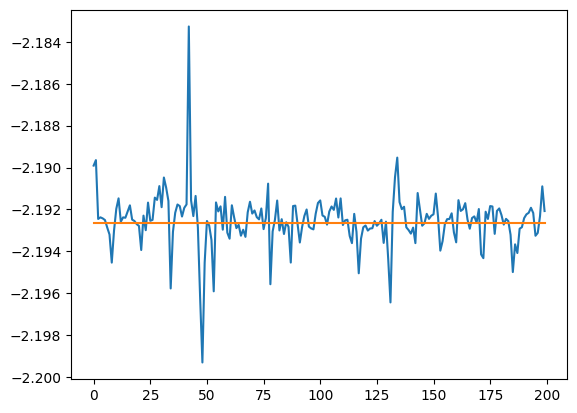

In [30]:
from matplotlib import pyplot as plt

# plt.plot(guide_block_e_sp)
plt.plot(trial_block_e_sp.real)
plt.plot([trial_e_avg]*len(trial_block_e_sp))

plt.show()

In [16]:
trial_energy_avg, trial_error = pt2ccsd_blocking(
    jnp.asarray(trial_block_w_sp), 
    ham_data.h0, 
    jnp.asarray(trial_block_t2_sp),
    jnp.asarray(trial_block_e0_sp), 
    jnp.asarray(trial_block_e1_sp), 
    printQ=True)

Performing Blocking Analysis for AFQMC/pt2CCSD energy...
blk_SZ  Nblk  Nsmp  Energy  Error
   1  200   200  -2.192532  0.000091
   2  100   200  -2.192557  0.000106
   3   66   198  -2.192578  0.000110
   4   50   200  -2.192585  0.000107
   5   40   200  -2.192585  0.000102
   6   33   198  -2.192596  0.000115
   7   28   196  -2.192595  0.000089
   8   25   200  -2.192599  0.000099
   9   22   198  -2.192612  0.000122
  10   20   200  -2.192597  0.000067
  11   18   198  -2.192622  0.000128
  12   16   192  -2.192624  0.000112
  13   15   195  -2.192613  0.000069
  14   14   196  -2.192617  0.000086
  15   13   195  -2.192617  0.000115
  16   12   192  -2.192620  0.000103
  17   11   187  -2.192629  0.000077
  18   11   198  -2.192624  0.000071
  19   10   190  -2.192637  0.000119
  20   10   200  -2.192618  0.000061
